In [ ]:
# Chạy cell này xong, nhớ nhấn 'Restart Session' ở menu Run
!pip install -q --force-reinstall "numpy<2.0.0" "xgboost<3.0.0" "lifelines<0.30.0" "xgbse==0.3.3"

In [ ]:
import os
import pandas as pd

base_path = "/kaggle/input/datasets/anhkhang/bich-data/analytical_dataset_with_notes/analytical_dataset_with_notes_2"

df_train = pd.read_parquet(os.path.join(base_path, "split=train"))
df_val = pd.read_parquet(os.path.join(base_path, "split=val"))
df_test = pd.read_parquet(os.path.join(base_path, "split=test"))

print(f"Train: {df_train.shape}")
print(f"Val: {df_val.shape}")
print(f"Test: {df_test.shape}")

Nạp dữ liệu từ Kaggle Storage vào RAM...
Train: (271739, 248)
Val: (57437, 248)
Test: (53875, 248)


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np

cat_cols_check = df_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
print(f"🔎 Cảnh báo: Phát hiện {len(cat_cols_check)} cột dạng chữ cần mã hóa: {cat_cols_check}\n")

def preprocess_data(df, is_train=False, imputer=None, cat_encoder=None):
    df_clean = df.copy()
    
    if 'gender' in df_clean.columns:
        df_clean['gender'] = df_clean['gender'].map({'F': 0, 'M': 1, 'Female': 0, 'Male': 1}).fillna(0)
        df_clean['gender'] = pd.to_numeric(df_clean['gender'], errors='coerce')
    
    T = df_clean['mortality_time_days']
    E = df_clean['mortality_event_12m'] 
    
    exclude_cols = [
        'subject_id', 'hadm_id', 'admittime', 'dischtime', 'index_time',
        'split', 'admityear', 'source_dataset',
        'readmission_time_days', 'readmission_event_30d',
        'mortality_time_days', 'mortality_time_months', 'mortality_event_12m',
        'next_admittime', 'days_to_next_admission',
        'dod', 'days_to_death_after_discharge',
        'event_flag_mortality', 'event_flag_readmission',
        'discharge_location_enc'
    ]
    
    feature_cols = [c for c in df_clean.columns if c not in exclude_cols]
    X = df_clean[feature_cols].copy()
    
    cat_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].fillna('Missing').astype(str)
        
    if is_train:
        cat_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        if len(cat_cols) > 0:
            X[cat_cols] = cat_encoder.fit_transform(X[cat_cols])
            
        imputer = SimpleImputer(strategy='median')
        X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
        
        return X_imputed, T, E, imputer, cat_encoder
    else:
        if len(cat_cols) > 0 and cat_encoder is not None:
            X[cat_cols] = cat_encoder.transform(X[cat_cols])
            
        X_imputed = pd.DataFrame(imputer.transform(X), columns=X.columns)
        return X_imputed, T, E

print("--- ĐANG TIỀN XỬ LÝ: BÀI TOÁN 12-MONTH MORTALITY ---")
# Hứng thêm fitted_encoder từ tập Train
X_train, T_train, E_train, fitted_imputer, fitted_encoder = preprocess_data(df_train, is_train=True)

X_val, T_val, E_val = preprocess_data(df_val, is_train=False, imputer=fitted_imputer, cat_encoder=fitted_encoder)
X_test, T_test, E_test = preprocess_data(df_test, is_train=False, imputer=fitted_imputer, cat_encoder=fitted_encoder)

print(f"✅ Xử lý xong!")
print(f"-> Tổng số Features đưa vào mô hình: {X_train.shape[1]} cột")
print(f"-> Target Event (E): {E_train.name}")
print(f"-> Target Time (T): {T_train.name} (Tối đa 365 ngày)")

🔎 Cảnh báo: Phát hiện 6 cột dạng chữ cần mã hóa: ['gender', 'admission_type', 'insurance', 'marital_status', 'race', 'discharge_location']

--- ĐANG TIỀN XỬ LÝ: BÀI TOÁN 12-MONTH MORTALITY ---
✅ Xử lý xong!
-> Tổng số Features đưa vào mô hình: 236 cột
-> Target Event (E): mortality_event_12m
-> Target Time (T): mortality_time_days (Tối đa 365 ngày)


In [5]:
from lifelines import CoxPHFitter

print("Đang huấn luyện mô hình Baseline (Cox PH)...")

train_cox_df = X_train.copy()
train_cox_df['T_duration'] = T_train.values
train_cox_df['E_event'] = E_train.values

val_cox_df = X_val.copy()
val_cox_df['T_duration'] = T_val.values
val_cox_df['E_event'] = E_val.values

test_cox_df = X_test.copy()
test_cox_df['T_duration'] = T_test.values
test_cox_df['E_event'] = E_test.values

cph = CoxPHFitter(penalizer=0.1)
cph.fit(train_cox_df, duration_col='T_duration', event_col='E_event')

train_c_index = cph.concordance_index_
val_c_index = cph.score(val_cox_df, scoring_method="concordance_index")
test_c_index = cph.score(test_cox_df, scoring_method="concordance_index")

print(f"\n[KẾT QUẢ BASELINE]")
print(f"-> C-index trên tập Train: {train_c_index:.4f}")
print(f"-> C-index trên tập Validation: {val_c_index:.4f}")
print(f"-> C-index trên tập Test: {test_c_index:.4f}")

Đang huấn luyện mô hình Baseline (Cox PH)...

[KẾT QUẢ BASELINE]
-> C-index trên tập Train: 0.8594
-> C-index trên tập Validation: 0.8594
-> C-index trên tập Test (Baseline CoxPH): 0.8521


--- ĐANG DỰ ĐOÁN VÀ VẼ ĐƯỜNG CONG SINH TỒN BASELINE (MORTALITY 12M) ---


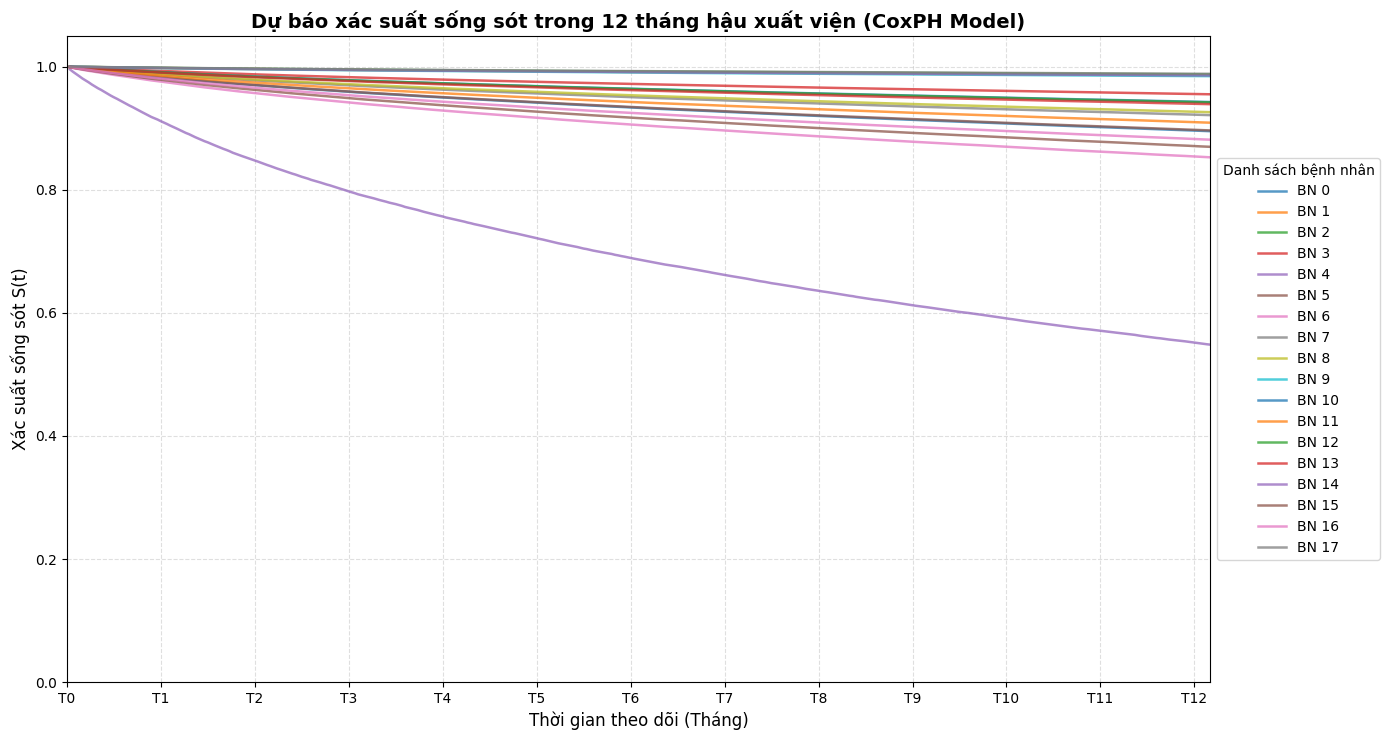


-> BN 0: Nguy cơ tử vong tích lũy tại mốc 12 tháng (Ngày thứ 365.0) là: 10.49%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("--- DỰ ĐOÁN, VẼ ĐƯỜNG CONG SINH TỒN BASELINE (MORTALITY 12M) ---")

test_patients = X_test.head(18)
patient_labels = [f"BN {i}" for i in test_patients.index]

if len(test_patients) == 0:
    print("Không có dữ liệu bệnh nhân.")
else:
    predicted = cph.predict_survival_function(test_patients)
    predicted.columns = patient_labels

    plt.figure(figsize=(14, 7.5))
    
    # Vẽ đường cong sinh tồn cho từng bệnh nhân (Trục index của 'predicted' là Ngày)
    for label in predicted.columns:
        plt.plot(predicted.index, predicted[label], linewidth=1.8, alpha=0.75, label=label)

    plt.title("Dự báo xác suất sống sót trong 12 tháng hậu xuất viện (CoxPH Model)", fontsize=14, fontweight='bold')
    plt.xlabel("Thời gian theo dõi (Tháng)", fontsize=12)
    plt.ylabel("Xác suất sống sót S(t)", fontsize=12)
    plt.xlim(0, 365) 
    
    month_ticks = np.arange(0, 366, 30)
    month_labels = [f"T{m//30}" for m in month_ticks]
    plt.xticks(month_ticks, month_labels)
    
    plt.ylim(0.0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Danh sách bệnh nhân", ncol=1)
    plt.tight_layout()
    plt.show()

    predicted_12m = predicted[predicted.index <= 365]

    if not predicted_12m.empty:
        # Lấy mốc ngày cuối cùng ghi nhận được sát mốc 365 ngày nhất
        last_day_recorded = predicted_12m.index[-1]
        
        # Rủi ro tử vong tích lũy = 1 - Xác suất sống sót tại thời điểm đó
        risk_12m = (1 - predicted_12m.iloc[-1, 0]) * 100
        print("\n" + "="*60)
        print(f"-> BN 0: Nguy cơ tử vong tích lũy tại mốc 12 tháng (Ngày thứ {last_day_recorded}) là: {risk_12m:.2f}%")
        print("="*60)
    else:
        print("-> Không có dữ liệu biến cố nào được ghi nhận trong phạm vi 12 tháng.")

In [7]:
import numpy as np

def transform_to_survival_label(T, E):
    y = np.empty(dtype=[('event', bool), ('duration', float)], shape=len(T))
    y['event'] = E.astype(bool)
    y['duration'] = T.astype(float)
    return y

print("Đang chuyển đổi nhãn sang định dạng Structured Array cho XGBSE...")
y_train = transform_to_survival_label(T_train, E_train)
y_val = transform_to_survival_label(T_val, E_val)
y_test = transform_to_survival_label(T_test, E_test)
print("Chuyển đổi thành công! Sẵn sàng đưa vào Optuna.")

Đang chuyển đổi nhãn sang định dạng Structured Array cho XGBSE...
Chuyển đổi thành công! Sẵn sàng đưa vào Optuna.


In [8]:
import optuna
import numpy as np
from xgbse import XGBSEStackedWeibull
from xgbse.metrics import concordance_index
import warnings

warnings.filterwarnings('ignore')

TIME_BINS = np.append(np.arange(30, 365, 30), 365)

def objective(trial):
    xgb_params = {
        'objective': 'survival:cox',
        'eval_metric': 'cox-nloglik',
        'tree_method': 'hist',
        'device': 'cuda', 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1), 
        'max_depth': trial.suggest_int('max_depth', 4, 8), 
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 50), 
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.9),
        'lambda': trial.suggest_float('lambda', 1e-2, 5.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-2, 5.0, log=True),
        'seed': 42
    }

    model = XGBSEStackedWeibull(xgb_params=xgb_params)

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        early_stopping_rounds=15, 
        time_bins=TIME_BINS
    )

    preds_val = model.predict(X_val)
    c_index = concordance_index(y_val, preds_val)
    return c_index

print("Đang khởi động Optuna để tối ưu bài toán 12-Month Mortality (10 vòng)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) 

print(f"\n[KẾT QUẢ THỬ NGHIỆM NHANH]")
print(f"C-index tốt nhất: {study.best_value:.4f}")
print("Tham số tối ưu:", study.best_params)

[I 2026-05-21 05:09:51,477] A new study created in memory with name: no-name-c00c4932-12a0-4fee-b4a0-b5dfce03e7c6


Đang khởi động Optuna để tối ưu bài toán 12-Month Mortality (10 vòng)...


[I 2026-05-21 05:10:18,953] Trial 0 finished with value: 0.8369453199584569 and parameters: {'learning_rate': 0.06691917585501422, 'max_depth': 4, 'min_child_weight': 46, 'subsample': 0.8518903461857288, 'colsample_bytree': 0.8495350530030235, 'lambda': 0.46714541952182287, 'alpha': 0.42367082751583857}. Best is trial 0 with value: 0.8369453199584569.
[I 2026-05-21 05:10:46,185] Trial 1 finished with value: 0.8430080103558216 and parameters: {'learning_rate': 0.03869018360615036, 'max_depth': 5, 'min_child_weight': 11, 'subsample': 0.8354374118819368, 'colsample_bytree': 0.7787479571014173, 'lambda': 0.02370663992062368, 'alpha': 1.5468701169590156}. Best is trial 1 with value: 0.8430080103558216.
[I 2026-05-21 05:11:13,254] Trial 2 finished with value: 0.8508120175776395 and parameters: {'learning_rate': 0.08392724480556156, 'max_depth': 6, 'min_child_weight': 22, 'subsample': 0.7739670571541822, 'colsample_bytree': 0.8611773237713152, 'lambda': 0.05127994110528411, 'alpha': 0.0126221


[KẾT QUẢ THỬ NGHIỆM NHANH]
C-index tốt nhất: 0.8508
Tham số tối ưu: {'learning_rate': 0.08392724480556156, 'max_depth': 6, 'min_child_weight': 22, 'subsample': 0.7739670571541822, 'colsample_bytree': 0.8611773237713152, 'lambda': 0.05127994110528411, 'alpha': 0.012622173225396927}


In [9]:
print("Đang huấn luyện mô hình Final với bộ tham số tốt nhất...")

best_params = study.best_params
best_params.update({
    'objective': 'survival:cox',
    'eval_metric': 'cox-nloglik',
    'tree_method': 'hist',
    'seed': 42
})

final_model = XGBSEStackedWeibull(xgb_params=best_params)
final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    early_stopping_rounds=10,
    time_bins=TIME_BINS
)

train_preds = final_model.predict(X_train)
val_preds = final_model.predict(X_val)
test_preds = final_model.predict(X_test)

from xgbse.metrics import concordance_index
train_c = concordance_index(y_train, train_preds)
val_c = concordance_index(y_val, val_preds)
test_c = concordance_index(y_test, test_preds)

print(f"\n[KẾT QUẢ MÔ HÌNH CHÍNH - XGBSE]")
print(f"-> C-index XGBSE (Train): {train_c:.4f}")
print(f"-> C-index XGBSE (Validation): {val_c:.4f}")
print(f"-> C-index XGBSE (Test): {test_c:.4f}")

if test_c >= 0.70:
    print(f"\n✅ ĐẠT KPI: C-index trên tập Test đạt {test_c:.4f} (Yêu cầu >= 0.70)")
else:
    print(f"\n⚠️ CẢNH BÁO: C-index hiện tại {test_c:.4f} chưa đạt ngưỡng 0.70. Cần tăng n_trials trong Optuna.")

Đang huấn luyện mô hình Final với bộ tham số tốt nhất...

[KẾT QUẢ MÔ HÌNH CHÍNH - XGBSE]
-> C-index XGBSE (Train): 0.8552
-> C-index XGBSE (Validation): 0.8509
-> C-index XGBSE (Test): 0.8441

✅ ĐẠT KPI: C-index trên tập Test đạt 0.8441 (Yêu cầu >= 0.70)


--- KHỞI ĐỘNG MODULE WHAT-IF SIMULATION (MORTALITY 12M) ---
👉 Ánh xạ các tùy chọn can thiệp sang mã số mã hóa: {'Về Nhà (HOME)': 5, 'Home Health Care (Điều dưỡng hỗ trợ)': 6, 'Viện Điều Dưỡng (SNF)': 12}



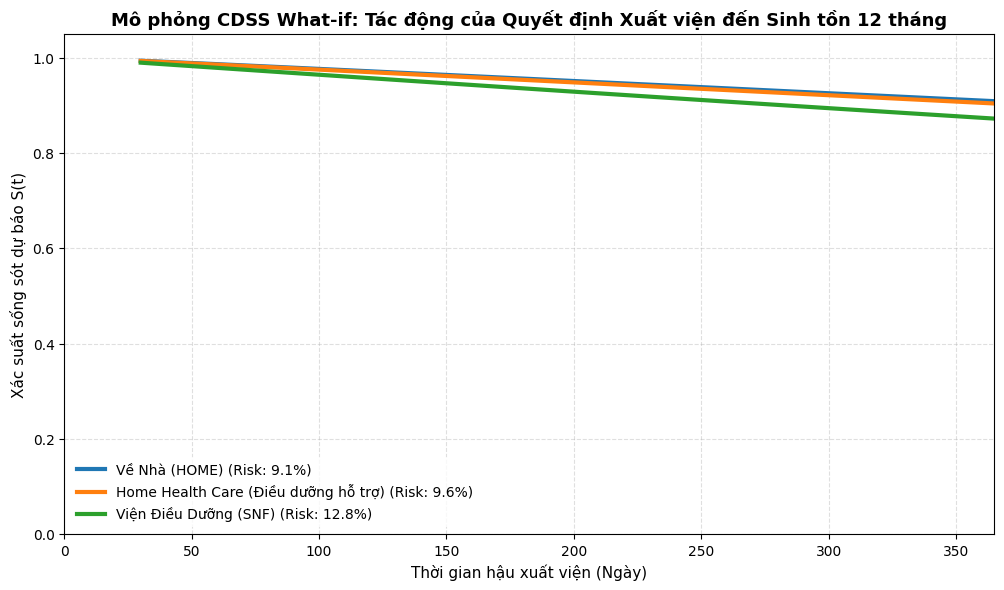

,Phương án Xuất viện (What-if),Risk Tử vong (12 tháng),RMST Score (Số ngày sống khỏe tích lũy)
0,Về Nhà (HOME),9.1%,369.9 ngày
1,Home Health Care (Điều dưỡng hỗ trợ),9.6%,368.8 ngày
2,Viện Điều Dưỡng (SNF),12.8%,361.2 ngày


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("--- KHỞI ĐỘNG MODULE WHAT-IF SIMULATION (MORTALITY 12M) ---")
encoder_features = list(fitted_encoder.feature_names_in_)

if 'discharge_location' in encoder_features:
    discharge_loc_idx = encoder_features.index('discharge_location')
    encoder_categories = fitted_encoder.categories_[discharge_loc_idx]
    
    def get_encoded_value(cat_name):
        for index, category in enumerate(encoder_categories):
            if str(category).strip().lower() == cat_name.strip().lower():
                return index
        
        for index, category in enumerate(encoder_categories):
            if cat_name.strip().lower() in str(category).strip().lower():
                return index
        return 0 
else:
    print("⚠️ Cảnh báo: Cột discharge_location đã ở dạng số sẵn.")
    def get_encoded_value(cat_name):
        return 0

options = {
    "Về Nhà (HOME)": get_encoded_value("HOME"),
    "Home Health Care (Điều dưỡng hỗ trợ)": get_encoded_value("HOME HEALTH CARE"),
    "Viện Điều Dưỡng (SNF)": get_encoded_value("SKILLED NURSING FACILITY")
}

print(f"👉 Ánh xạ các tùy chọn can thiệp sang mã số mã hóa: {options}\n")

patient_idx = 0
base_patient = X_test.iloc[[patient_idx]].copy()

results = []
plt.figure(figsize=(12, 6.5))

for opt_name, opt_val in options.items():
    simulated_patient = base_patient.copy()
    
    if 'discharge_location' in simulated_patient.columns:
        simulated_patient['discharge_location'] = opt_val
    
    pred_survival = final_model.predict(simulated_patient)
    
    risk_12m = 1 - pred_survival.iloc[0, -1]
    rmst_12m = pred_survival.iloc[0].sum() * 30 
    
    results.append({
        "Phương án Xuất viện (What-if)": opt_name,
        "Risk Tử vong (12 tháng)": f"{risk_12m * 100:.1f}%",
        "RMST Score (Số ngày sống khỏe tích lũy)": f"{rmst_12m:.1f} ngày"
    })
    
    plt.plot(pred_survival.columns, pred_survival.iloc[0], label=f"{opt_name} (Risk: {risk_12m*100:.1f}%)", linewidth=3)

plt.title("Mô phỏng CDSS What-if: Tác động của Quyết định Xuất viện đến Sinh tồn 12 tháng", fontsize=13, fontweight='bold')
plt.xlabel("Thời gian hậu xuất viện (Ngày)", fontsize=11)
plt.ylabel("Xác suất sống sót dự báo S(t)", fontsize=11)
plt.xlim(0, 365)
plt.ylim(0, 1.05)
plt.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

df_results = pd.DataFrame(results)
display(df_results)

In [ ]:
import numpy as np
import pandas as pd

print("--- TIẾN HÀNH KIỂM TRA LỆNH TÍNH RMST TỪ MODEL ĐÃ HUẤN LUYỆN ---")
single_patient = X_test.iloc[[0]].copy()
pred_survival = final_model.predict(single_patient)

display(pred_survival)

print("BẮT ĐẦU CHẠY CÁC THUẬT TOÁN TÍNH RMST")

delta_t = 30 
rmst_days_thong_thuong = pred_survival.iloc[0].sum() * delta_t

print(f"👉 Cách 1 (Tính thô Riemann): RMST = {rmst_days_thong_thuong:.2f} ngày")


times = pred_survival.columns.astype(float) # Sẽ là mảng [30.0, 60.0, ..., 365.0]
probabilities = pred_survival.iloc[0].values # Mảng 12 con số xác suất từ 0 đến 1

all_times = np.insert(times, 0, 0.0)
all_probs = np.insert(probabilities, 0, 1.0)

rmst_days_chuan_xac = np.trapz(all_probs, all_times)

print(f"👉 Cách 2 (Diện tích hình thang AUC): RMST = {rmst_days_chuan_xac:.2f} ngày")

In [ ]:
import joblib
import os

model_dir = "mortality_models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

print("--- ĐANG ĐÓNG GÓI MÔ HÌNH ---")

# Lưu bộ tiền xử lý
joblib.dump(fitted_imputer, os.path.join(model_dir, "fitted_imputer.joblib"))
print("Đã lưu: SimpleImputer (Pre-processor)")

# Lưu mô hình Baseline (Cox PH)
joblib.dump(cph, os.path.join(model_dir, "baseline_cox_model.joblib"))
print("Đã lưu: Baseline CoxPH Model")

# Lưu mô hình Final (XGBSE)
# XGBSEStackedWeibull chứa các cây XGBoost và tham số Weibull
joblib.dump(final_model, os.path.join(model_dir, "final_xgbse_model.joblib"))
print("Đã lưu: Final XGBSE Model")

!zip -r mortality_models_export.zip {model_dir}

print("-> Vào tab 'Output' bên phải màn hình Kaggle để tải file 'mortality_models_export.zip'.")
print("-> Bao gồm: Pre-processor, Baseline Model và XGBSE Final Model.")

--- ĐANG ĐÓNG GÓI MÔ HÌNH ---
Đã lưu: SimpleImputer (Pre-processor)
Đã lưu: Baseline CoxPH Model
Đã lưu: Final XGBSE Model
  adding: mortality_models/ (stored 0%)
  adding: mortality_models/baseline_cox_model.joblib (deflated 82%)
  adding: mortality_models/fitted_imputer.joblib (deflated 53%)
  adding: mortality_models/final_xgbse_model.joblib (deflated 80%)
-> Bạn hãy vào tab 'Output' bên phải màn hình Kaggle để tải file 'survival_models_export.zip'.
-> File này bao gồm: Pre-processor, Baseline Model và XGBSE Final Model.
